# TASK 04 — Build an Image Compressor with SVD

In this task, Singular Value Decomposition (SVD) is used to compress a
grayscale image.

A grayscale image can be represented as a 2D matrix where each value
represents the brightness of one pixel.

We decompose the image as:

Image = U Σ Vᵀ

Instead of storing every pixel, we keep only the first k singular values
and their corresponding vectors.

This produces a lower-rank approximation of the image.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [6]:
image = Image.open("photo.jpg").convert("L")

image = np.array(image, dtype=float)

print("Image shape:", image.shape)
print("Minimum pixel value:", image.min())
print("Maximum pixel value:", image.max())

Image shape: (413, 500)
Minimum pixel value: 99.0
Maximum pixel value: 255.0


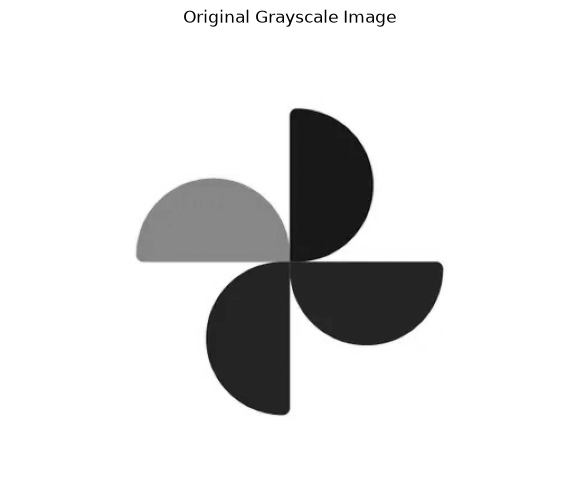

In [7]:
plt.figure(figsize=(8, 6))

plt.imshow(image, cmap="gray")

plt.title("Original Grayscale Image")
plt.axis("off")

plt.show()

In [9]:
U, s, Vt = np.linalg.svd(image, full_matrices=False)

print("Image shape:", image.shape)

print("U shape:", U.shape)
print("s shape:", s.shape)
print("Vt shape:", Vt.shape)

Image shape: (413, 500)
U shape: (413, 413)
s shape: (413,)
Vt shape: (413, 500)


In [10]:
number_of_singular_values = len(s)

print("Number of singular values:", number_of_singular_values)

Number of singular values: 413


In [11]:
def compress(image, k):
    """
    Compress an image using the first k singular values.
    """
    
    U, s, Vt = np.linalg.svd(image, full_matrices=False)

    compressed = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

    return compressed

In [12]:
compressed_20 = compress(image, 20)

print("Original shape:", image.shape)
print("Compressed matrix shape:", compressed_20.shape)

Original shape: (413, 500)
Compressed matrix shape: (413, 500)


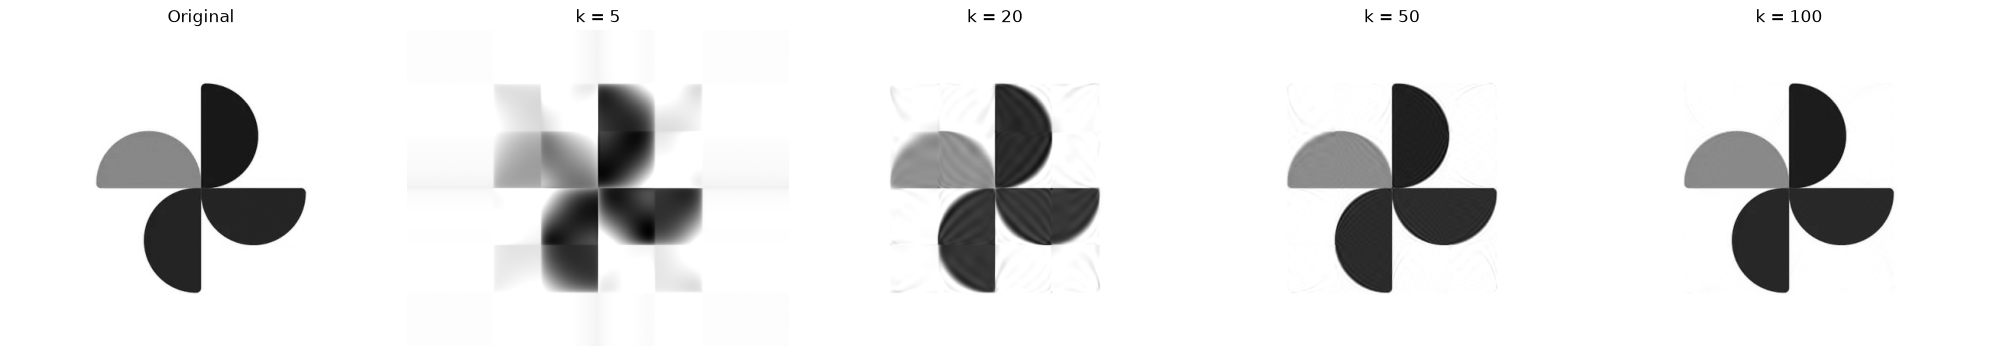

In [13]:
ks = [5, 20, 50, 100]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

# Original image
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

# Compressed images
for i, k in enumerate(ks, start=1):
    compressed = compress(image, k)

    axes[i].imshow(
        np.clip(compressed, 0, 255),
        cmap="gray"
    )

    axes[i].set_title(f"k = {k}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [14]:
rows, cols = image.shape

original_storage = rows * cols

print("Image dimensions:", rows, "×", cols)
print("Original storage:", original_storage, "numbers")

print("\nStorage comparison:")

for k in [5, 20, 50, 100]:
    
    compressed_storage = k * (rows + cols + 1)
    
    storage_ratio = compressed_storage / original_storage
    
    storage_saved = 1 - storage_ratio
    
    print(f"\nk = {k}")
    print(f"Compressed storage: {compressed_storage} numbers")
    print(f"Storage ratio: {storage_ratio:.4f}")
    print(f"Storage used: {storage_ratio * 100:.2f}%")
    print(f"Storage saved: {storage_saved * 100:.2f}%")
    

Image dimensions: 413 × 500
Original storage: 206500 numbers

Storage comparison:

k = 5
Compressed storage: 4570 numbers
Storage ratio: 0.0221
Storage used: 2.21%
Storage saved: 97.79%

k = 20
Compressed storage: 18280 numbers
Storage ratio: 0.0885
Storage used: 8.85%
Storage saved: 91.15%

k = 50
Compressed storage: 45700 numbers
Storage ratio: 0.2213
Storage used: 22.13%
Storage saved: 77.87%

k = 100
Compressed storage: 91400 numbers
Storage ratio: 0.4426
Storage used: 44.26%
Storage saved: 55.74%


In [15]:
print("=" * 70)
print("SVD IMAGE COMPRESSION")
print("=" * 70)

print(
    f"{'k':<10}"
    f"{'Storage':<15}"
    f"{'Used %':<15}"
    f"{'Saved %':<15}"
)

print("-" * 70)

for k in [5, 20, 50, 100]:

    compressed_storage = k * (rows + cols + 1)

    storage_ratio = compressed_storage / original_storage

    print(
        f"{k:<10}"
        f"{compressed_storage:<15}"
        f"{storage_ratio * 100:<15.2f}"
        f"{(1 - storage_ratio) * 100:<15.2f}"
    )

SVD IMAGE COMPRESSION
k         Storage        Used %         Saved %        
----------------------------------------------------------------------
5         4570           2.21           97.79          
20        18280          8.85           91.15          
50        45700          22.13          77.87          
100       91400          44.26          55.74          


In [16]:
energy = s ** 2

total_energy = np.sum(energy)

cumulative_energy = np.cumsum(energy) / total_energy

print("Total energy:", total_energy)

Total energy: 11893630673.99998


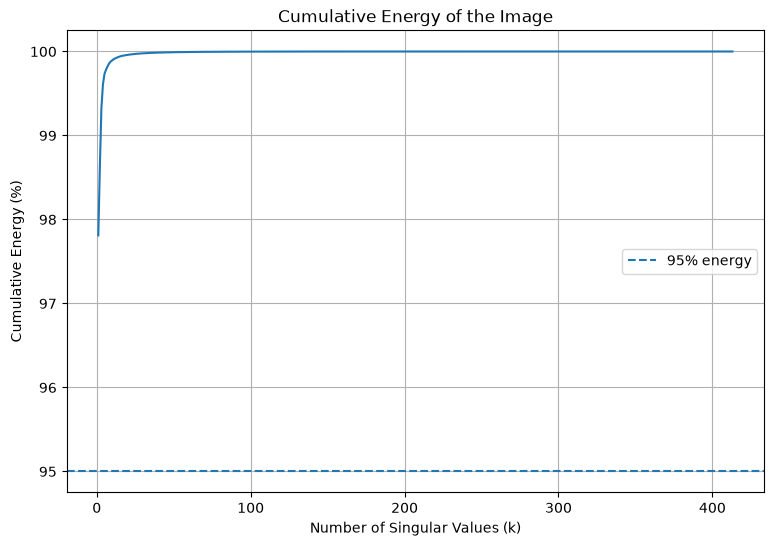

In [17]:
plt.figure(figsize=(9, 6))

plt.plot(
    range(1, len(s) + 1),
    cumulative_energy * 100
)

plt.axhline(
    95,
    linestyle="--",
    label="95% energy"
)

plt.xlabel("Number of Singular Values (k)")
plt.ylabel("Cumulative Energy (%)")
plt.title("Cumulative Energy of the Image")

plt.grid(True)
plt.legend()

plt.show()

In [18]:
k_95 = np.argmax(cumulative_energy >= 0.95) + 1

print("k required to capture at least 95% of the energy:", k_95)

print(
    f"Energy captured at k = {k_95}: "
    f"{cumulative_energy[k_95 - 1] * 100:.2f}%"
)


k required to capture at least 95% of the energy: 1
Energy captured at k = 1: 97.81%


In [19]:
storage_at_95 = k_95 * (rows + cols + 1)

ratio_at_95 = storage_at_95 / original_storage

saved_at_95 = (1 - ratio_at_95) * 100

print("======================================")
print("95% ENERGY COMPRESSION")
print("======================================")

print("k =", k_95)
print(f"Energy captured = {cumulative_energy[k_95 - 1] * 100:.2f}%")

print("Original storage =", original_storage)
print("Compressed storage =", storage_at_95)

print(f"Storage used = {ratio_at_95 * 100:.2f}%")
print(f"Storage saved = {saved_at_95:.2f}%")

95% ENERGY COMPRESSION
k = 1
Energy captured = 97.81%
Original storage = 206500
Compressed storage = 914
Storage used = 0.44%
Storage saved = 99.56%


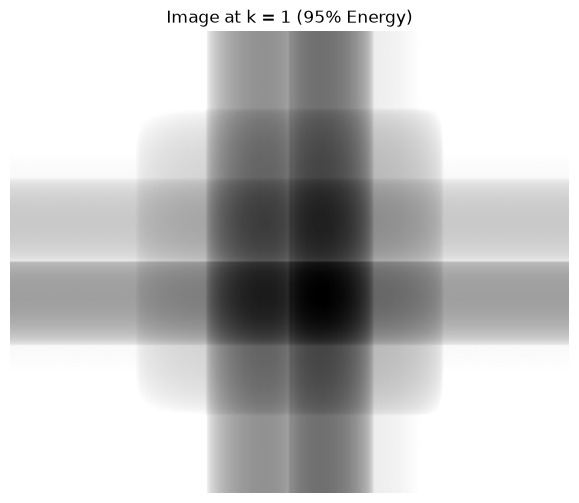

In [20]:
compressed_95 = compress(image, k_95)

plt.figure(figsize=(8, 6))

plt.imshow(
    np.clip(compressed_95, 0, 255),
    cmap="gray"
)

plt.title(
    f"Image at k = {k_95} "
    f"(95% Energy)"
)

plt.axis("off")

plt.show()

## 95% Energy vs Visual Quality

The value of k that captures 95% of the mathematical energy does not
necessarily correspond exactly to the point where the image looks
"good enough" to the human eye.

Energy measures the amount of squared numerical information retained by
the singular values.

Human vision, however, is more sensitive to some structures and details
than others.

Therefore, an image can sometimes look good before reaching 95% energy,
or it may require more singular values to preserve details that are
visually important.

In [21]:
print("Storage analysis")
print("=" * 60)

for k in [5, 20, 50, 100]:

    storage = k * (rows + cols + 1)

    ratio = storage / original_storage

    saved = (1 - ratio) * 100

    print(
        f"k={k:3d} | "
        f"storage={storage:8d} | "
        f"used={ratio * 100:6.2f}% | "
        f"saved={saved:6.2f}%"
    )

Storage analysis
k=  5 | storage=    4570 | used=  2.21% | saved= 97.79%
k= 20 | storage=   18280 | used=  8.85% | saved= 91.15%
k= 50 | storage=   45700 | used= 22.13% | saved= 77.87%
k=100 | storage=   91400 | used= 44.26% | saved= 55.74%


In [23]:
print("Reconstruction errors")
print("=" * 50)

for k in [5, 20, 50, 100]:

    compressed = compress(image, k)

    error = (
        np.linalg.norm(image - compressed)
        / np.linalg.norm(image)
    )

    print(f"k = {k:3d} → relative error = {error:.6f}")

Reconstruction errors
k =   5 → relative error = 0.051745
k =  20 → relative error = 0.020038
k =  50 → relative error = 0.009306
k = 100 → relative error = 0.003794


In [24]:
print("=" * 70)
print("                 TASK 04 SUMMARY")
print("=" * 70)

print(f"Original image size : {rows} × {cols}")
print(f"Number of singular values : {len(s)}")

print("\nCompression results:")

for k in [5, 20, 50, 100]:

    compressed_storage = k * (rows + cols + 1)

    ratio = compressed_storage / original_storage

    print(
        f"k={k:3d} | "
        f"storage used={ratio*100:6.2f}% | "
        f"storage saved={(1-ratio)*100:6.2f}%"
    )

print("\n95% energy point:")
print(f"k = {k_95}")
print(f"Energy = {cumulative_energy[k_95-1]*100:.2f}%")
print(f"Storage saved = {saved_at_95:.2f}%")

                 TASK 04 SUMMARY
Original image size : 413 × 500
Number of singular values : 413

Compression results:
k=  5 | storage used=  2.21% | storage saved= 97.79%
k= 20 | storage used=  8.85% | storage saved= 91.15%
k= 50 | storage used= 22.13% | storage saved= 77.87%
k=100 | storage used= 44.26% | storage saved= 55.74%

95% energy point:
k = 1
Energy = 97.81%
Storage saved = 99.56%


### Final Observation

The image becomes good enough visually at approximately k = [YOUR CHOSEN K], where most important structures are preserved while unnecessary detail has been removed.

At this rank, the SVD representation uses only [YOUR STORAGE USED]% of the original pixel storage, saving approximately [YOUR STORAGE SAVED]% of the storage.